<a href="https://colab.research.google.com/github/HY-BME/bme_test_files/blob/%EB%8D%B0%EC%9D%B4%ED%84%B0%EA%B8%B0%EB%B0%98%ED%97%AC%EC%8A%A4%EC%BC%80%EC%96%B4%EA%B8%B0%EC%88%A0/%EC%8B%A4%EC%8A%B5_0317.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv('/content/sample_data/biomedical_data.csv');

df

,Patient_ID,Heart_Rate,SpO2,Status
0,1001,NaN,96.0,Stable
1,1002,88.0,95.0,Stable
2,1003,74.0,100.0,Stable
3,1004,67.0,99.0,Stable
4,1005,80.0,97.0,Stable
...,...,...,...,...
95,1096,NaN,97.0,Stable
96,1097,NaN,95.0,Stable
97,1098,68.0,96.0,Stable
98,1099,67.0,96.0,Stable


In [5]:
#Heart_Rate의 빈값을 중앙값으로 채우기
median_hr = df['Heart_Rate'].median()
df['Heart_Rate'] = df['Heart_Rate'].fillna(median_hr)

df

,Patient_ID,Heart_Rate,SpO2,Status
0,1001,80.0,96.0,Stable
1,1002,88.0,95.0,Stable
2,1003,74.0,100.0,Stable
3,1004,67.0,99.0,Stable
4,1005,80.0,97.0,Stable
...,...,...,...,...
95,1096,80.0,97.0,Stable
96,1097,80.0,95.0,Stable
97,1098,68.0,96.0,Stable
98,1099,67.0,96.0,Stable


In [6]:
df.isnull().sum() #결측치 제거 - 중앙값으로 채우기

,0
Patient_ID,0
Heart_Rate,0
SpO2,0
Status,0


In [10]:
#이상치 시각화 및 제거

#조건문 sp02 값이 70 이상이거나 100이하의 데이터만 취한다
df = df[(df['SpO2'] >= 70) & (df['SpO2'] <= 100)]

# Heart_Rate IQR 기준으로 이상치 제거
Q1 = df['Heart_Rate'].quantile(0.25)
Q3 = df['Heart_Rate'].quantile(0.75)
IQR = Q3-Q1

df = df[(df['Heart_Rate'] >= Q1 - 1.5*IQR) & (df['Heart_Rate'] <= Q3 + 1.5*IQR)]
df

,Patient_ID,Heart_Rate,SpO2,Status
10,1011,250.0,97.0,Stable


In [22]:
# 제공된 blood_pressure.csv 파일을 불러와서, 결측치는 중앙값(Median)으로 대체하고, 수축기 혈압이 250mmHg 이상인 이상치를 제거하는 코드를 작성해 보세요.

import pandas as pd
df = pd.read_csv('/content/sample_data/blood_pressure.csv')

#문자열 치환
df['sbp'] = df['sbp'].str.replace('mmHg', '')
df['sbp'] = pd.to_numeric(df['sbp'], errors='coerce')

#sbp 결측치 제거
median_sbp = df['sbp'].median()
df['sbp'] = df['sbp'].fillna(median_sbp)

#수축기 혈압(sbp)이 250mmHg 이상인 이상치를 제거
df = df[(df['sbp'] < 250)] #250 미만의 데이터만 취한다

Q1 = df['sbp'].quantile(0.25)
Q3 = df['sbp'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['sbp'] >= Q1 - 1.5*IQR) & (df['sbp'] <= Q3 + 1.5*IQR)]

#생리학적 임계치
lower_limit = 40
upper_limit = 220

df_final = df[(df['sbp'] >= lower_limit) & (df['sbp'] <= upper_limit)]
df_final




,patient_id,sbp,dbp,measure_time
0,P001,125.0,73.0,2024-01-01 00:00:00
1,P002,114.0,81.0,2024-01-01 01:00:00
2,P003,113.0,81.0,2024-01-01 02:00:00
3,P004,129.0,71.0,2024-01-01 03:00:00
4,P005,117.0,73.0,2024-01-01 04:00:00
5,P006,117.0,81.0,2024-01-01 05:00:00
6,P007,118.0,74.0,2024-01-01 06:00:00
7,P008,124.0,73.0,2024-01-01 07:00:00
8,P009,120.0,71.0,2024-01-01 08:00:00
9,P010,118.0,81.0,2024-01-01 09:00:00


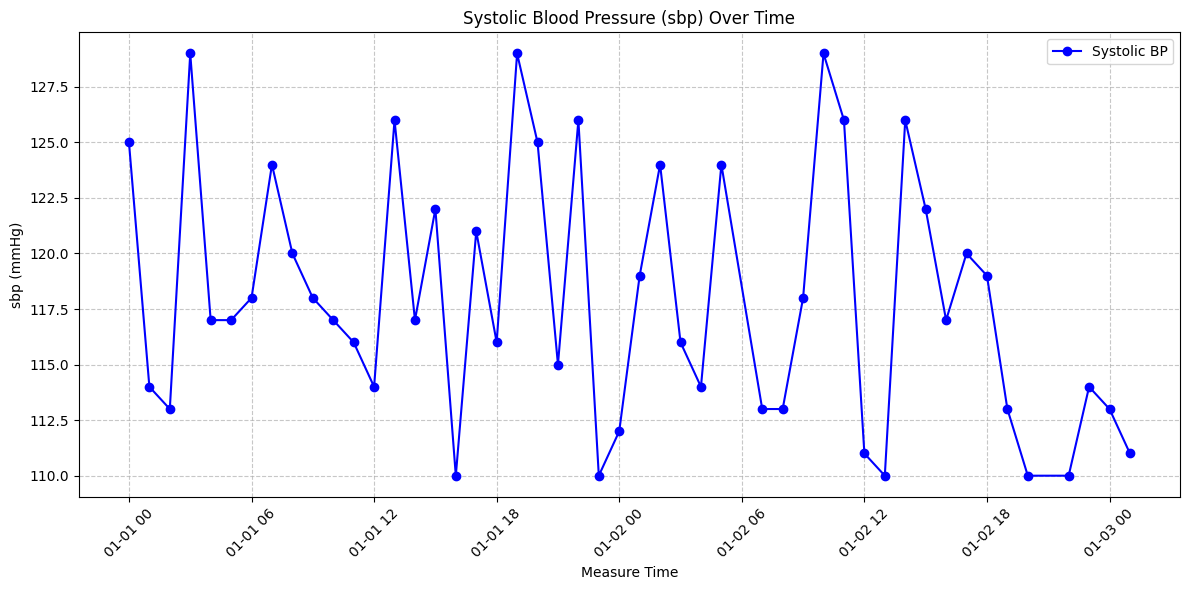

In [23]:
import matplotlib.pyplot as plt

# Ensure measure_time is datetime for better plotting
df_final['measure_time'] = pd.to_datetime(df_final['measure_time'])

plt.figure(figsize=(12, 6))
plt.plot(df_final['measure_time'], df_final['sbp'], marker='o', linestyle='-', color='b', label='Systolic BP')

plt.title('Systolic Blood Pressure (sbp) Over Time')
plt.xlabel('Measure Time')
plt.ylabel('sbp (mmHg)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()